# HW5 - Lunar Lander Reinforcement Learning

For this homework we will be applying reinforcement learning to the lunar lander environment.

In [1]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 47.8 MB/s eta 0:00:00


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.animation
import matplotlib.pyplot as plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')
import gymnasium as gym

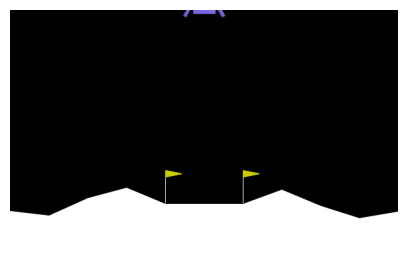

In [3]:
env = gym.make('LunarLander-v3', render_mode="rgb_array")
obs, info = env.reset()

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

In [4]:
print("Lander coordinates: ", obs[0], obs[1])
print("Lander velocities: ", obs[2], obs[3])
print("Lander angle: ", obs[4])
print("Lander angular velocity: ", obs[5])
print("Legs touching ground?: ", obs[6], obs[7])

Lander coordinates:  0.0011788368 1.420304
Lander velocities:  0.11939156 0.41706178
Lander angle:  -0.0013592067
Lander angular velocity:  -0.027043933
Legs touching ground?:  0.0 0.0


### Action Space:

0. do nothing
1. fire left engine
2. fire main engine
3. fire right engine

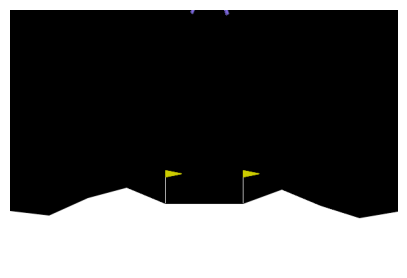

Lander coordinates:  0.030660057 1.4604369
Lander velocities:  0.119274184 -0.24960883
Lander angle:  -0.034693614
Lander angular velocity:  -0.026622403
Legs touching ground?:  0.0 0.0
Reward:  -2.036149449186013


In [5]:
for x in range(25):
    obs, reward, done, truncated, info = env.step(0)
plot_environment(env)
plt.show()
print("Lander coordinates: ", obs[0], obs[1])
print("Lander velocities: ", obs[2], obs[3])
print("Lander angle: ", obs[4])
print("Lander angular velocity: ", obs[5])
print("Legs touching ground?: ", obs[6], obs[7])
print("Reward: ", reward)

### Write a better basic_policy than the one below.  

Rewards are given for:
1. Distance to landing pad (closer is better)
2. Speed of lander (slower is better)
3. Penalty for how far the lander is tilted
4. +10 pts for each leg touching ground
5. -0.03 pts for each step in which a side engine is firing
6. -0.3 pts for each step in which the main engine is firing
7. -100 for crashing
8. +100 for landing safely

Full credit is given for a basic policy which achieves a mean total > 0.  Partial credit given for basic policies which achieve mean scores below 0.

In [6]:
def basic_policy(obs):
    x, y, vx, vy, ang, angV, lleg, rleg = obs

    target_ang = 0.5 * x + 0.5 * vx

    if (ang - target_ang) + angV < -0.05:
        return 1
    if (ang - target_ang) + angV > 0.05:
        return 3

    if vy < -0.25:
        return 2

    return 0


totals = []
for episode in range(100):
    episode_rewards = 0
    obs, info = env.reset(seed=episode)
    for step in range(200):
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        episode_rewards += reward
        if done or truncated:
            break

    totals.append(episode_rewards)

print("Mean total score: ", np.mean(totals))

def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = matplotlib.animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

def show_one_episode(policy, n_max_steps=200):
    frames = []
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, info = env.reset()
    score = 0
    for step in range(n_max_steps):
        frames.append(env.render())
        action = policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        score += reward
        if done or truncated:
            break
    env.close()
    return plot_animation(frames)

show_one_episode(basic_policy)

Mean total score:  101.07262540144698


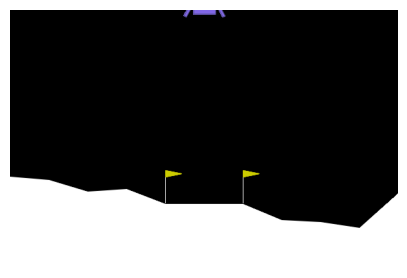

[ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]


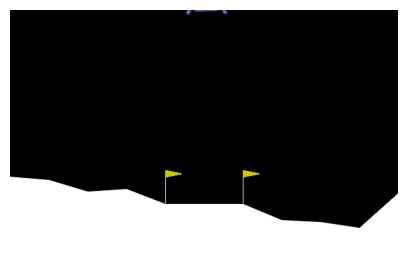

[0.01275616 1.4453568  0.20050585 0.18886034 0.01011833 0.07544497
 0.         0.        ]


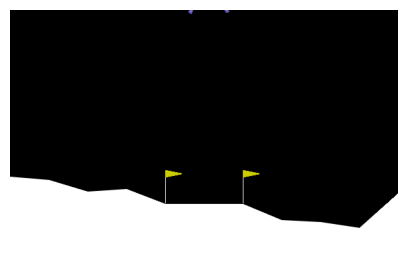

[0.0229702  1.4576083  0.20045057 0.05551349 0.02896909 0.07538629
 0.         0.        ]


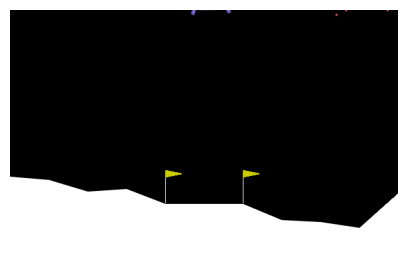

[ 0.03318119  1.4548637   0.20039609 -0.07783541  0.04780526  0.07532835
  0.          0.        ]


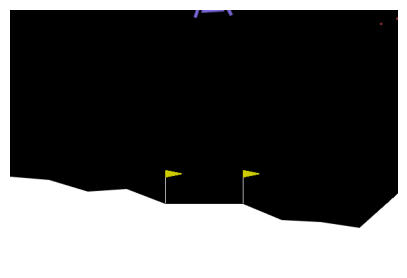

[ 0.04338932  1.4371223   0.2003428  -0.21118598  0.06662714  0.07527159
  0.          0.        ]


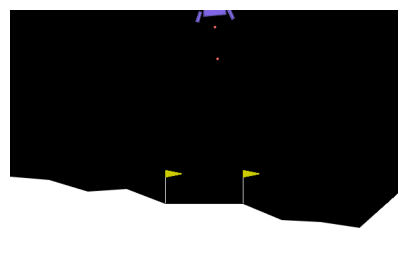

[ 0.05333748  1.4092133   0.18874471 -0.23842542  0.08538056  0.07605968
  0.          0.        ]


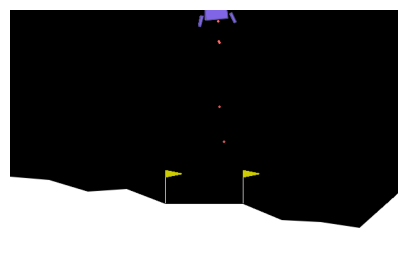

[ 0.06252155  1.3784543   0.1725809  -0.28796148  0.09967643  0.02885549
  0.          0.        ]


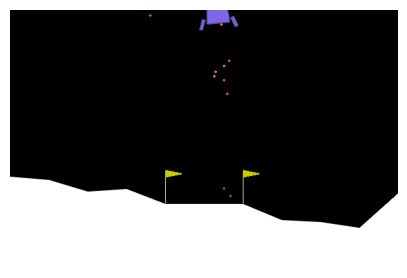

[ 0.07081127  1.3498763   0.14525253 -0.2574969   0.10900965  0.02693122
  0.          0.        ]


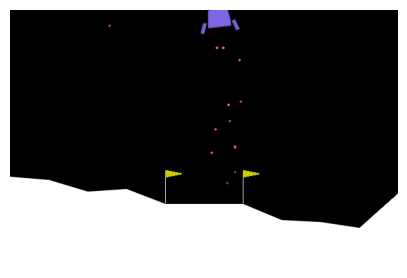

[ 0.07743321  1.3223112   0.12476192 -0.26007557  0.1160163   0.02827282
  0.          0.        ]


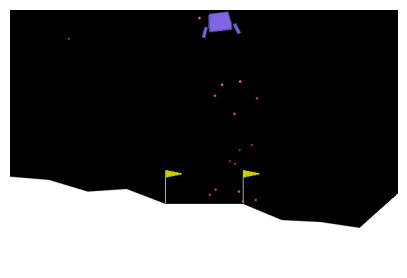

[ 0.08260441  1.2928841   0.10978472 -0.28770965  0.11840565 -0.02319023
  0.          0.        ]


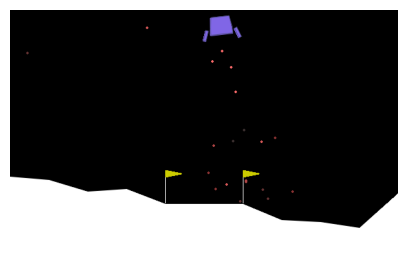

[ 0.08699302  1.2635821   0.08140328 -0.26806614  0.11216863 -0.02463827
  0.          0.        ]


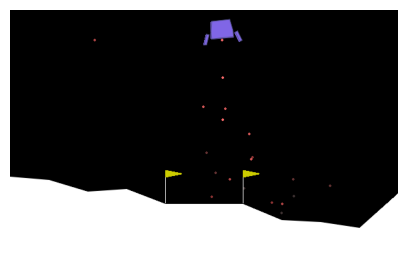

[ 0.09077511  1.2350193   0.07161776 -0.2668695   0.10861096 -0.01236542
  0.          0.        ]


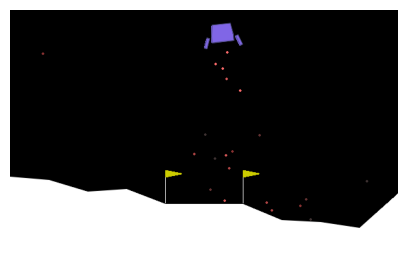

[ 0.09337234  1.2060304   0.03674247 -0.2529543   0.10446274 -0.02313327
  0.          0.        ]


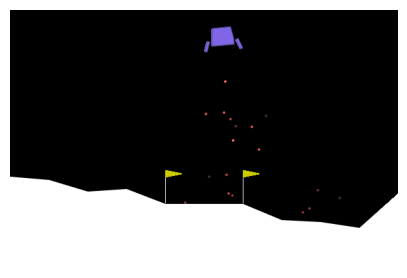

[ 0.09443712  1.1791728   0.01785279 -0.2518877   0.09877566 -0.02129084
  0.          0.        ]


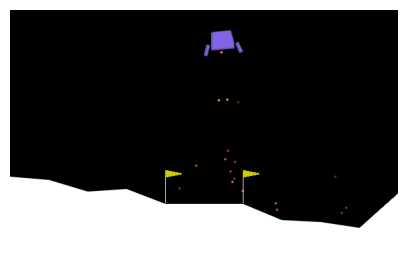

[ 0.09521113  1.1510316   0.01945901 -0.255583    0.09592485 -0.00140487
  0.          0.        ]


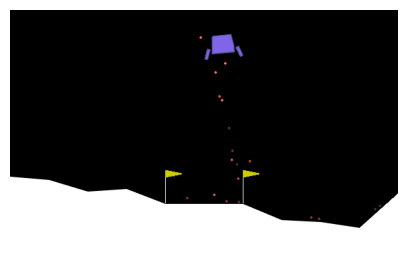

[ 0.09654236  1.1204646   0.02610502 -0.27435154  0.09574679 -0.01693641
  0.          0.        ]


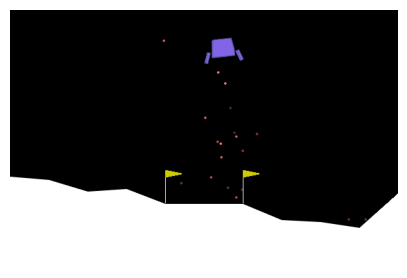

[ 0.09799509  1.0917175   0.03322773 -0.27255344  0.09566192  0.00869256
  0.          0.        ]


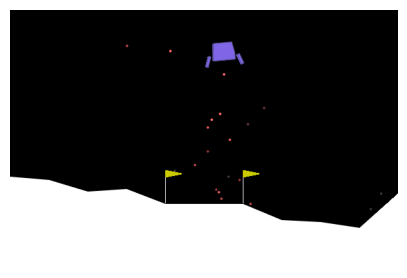

[ 1.0073395e-01  1.0629098e+00  5.6482501e-02 -2.3551352e-01
  9.5275007e-02 -8.4565149e-04  0.0000000e+00  0.0000000e+00]


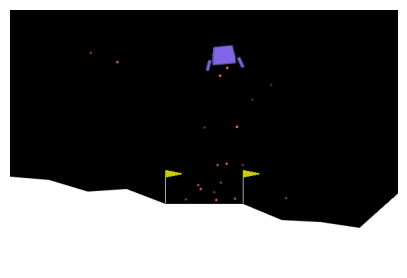

[ 0.10287847  1.0345708   0.03192911 -0.2522988   0.09403947 -0.00849004
  0.          0.        ]


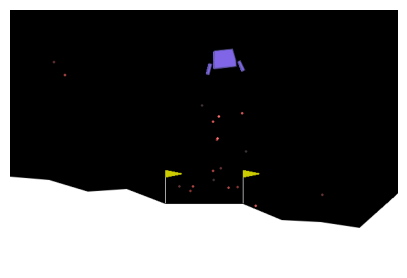

[ 0.1050334   1.0070928   0.04556478 -0.27350754  0.09746523  0.02007185
  0.          0.        ]


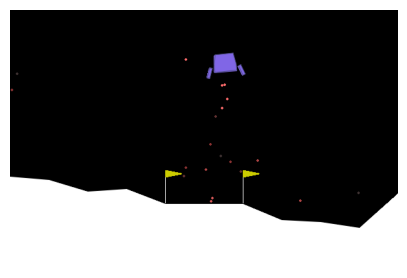

[ 0.10767813  0.9760975   0.05911282 -0.25731885  0.09922642  0.00308932
  0.          0.        ]


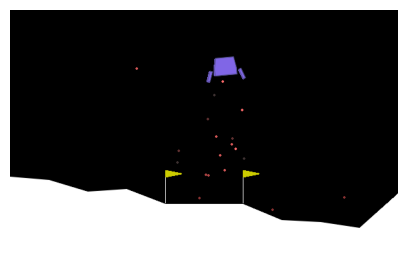

[ 0.10929947  0.94812083  0.03773188 -0.25884342  0.0968552   0.00129212
  0.          0.        ]


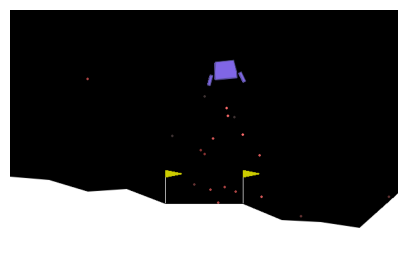

[ 0.11010609  0.9204766   0.0082823  -0.2477569   0.09531263 -0.00687817
  0.          0.        ]


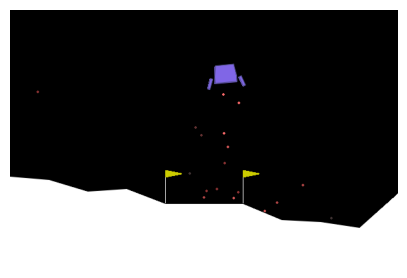

[ 0.10992136  0.8910658  -0.00157868 -0.24347879  0.09308072  0.00237185
  0.          0.        ]


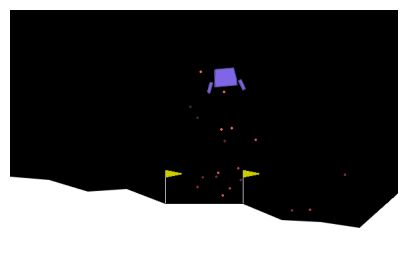

[ 0.10986795  0.8627741   0.00777916 -0.24695686  0.09196731 -0.01424767
  0.          0.        ]


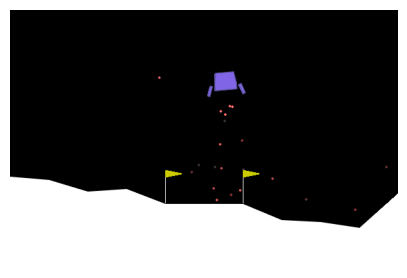

[ 0.10987272  0.83356947 -0.0233846  -0.22100061  0.08892206 -0.02338192
  0.          0.        ]


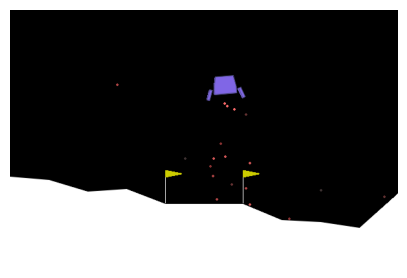

[ 0.10808258  0.80378765 -0.04867826 -0.24869034  0.08155999 -0.03485328
  0.          0.        ]


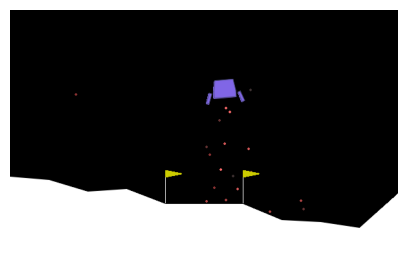

[ 0.10541534  0.77524567 -0.06543414 -0.23407955  0.07423155 -0.03426517
  0.          0.        ]


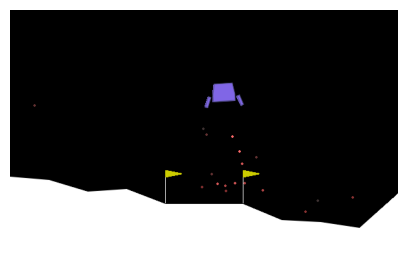

[ 0.10084419  0.7470742  -0.10506092 -0.2548722   0.06162873 -0.06120294
  0.          0.        ]


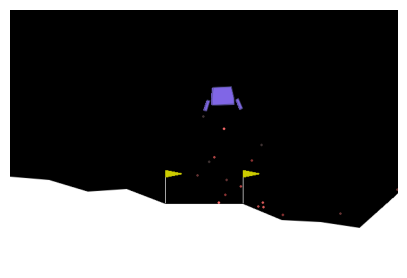

[ 0.09559955  0.7193522  -0.10437236 -0.2707187   0.04892571 -0.05052022
  0.          0.        ]


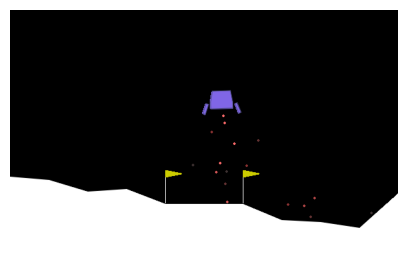

[ 0.0895072   0.69014996 -0.13251802 -0.25321594  0.03430795 -0.06822793
  0.          0.        ]


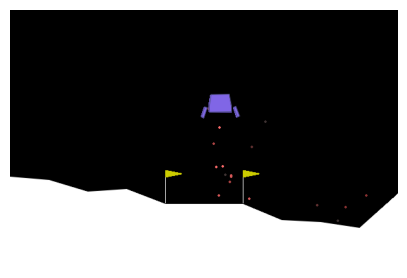

[ 0.08287211  0.66315025 -0.12838373 -0.21655872  0.01898127 -0.05743613
  0.          0.        ]


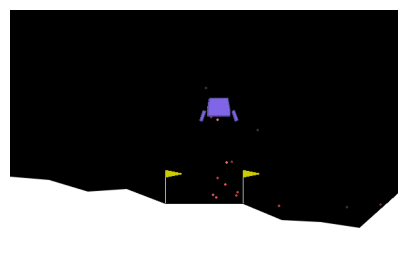

[ 0.07598667  0.63432586 -0.13617784 -0.26296365  0.00331109 -0.0636026
  0.          0.        ]


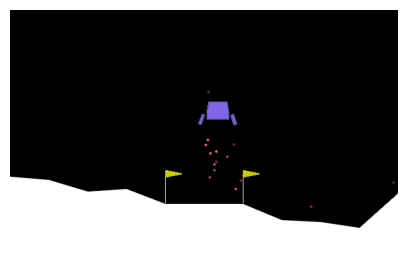

[ 0.07063331  0.60604864 -0.09382431 -0.25098944 -0.00510524 -0.02263108
  0.          0.        ]


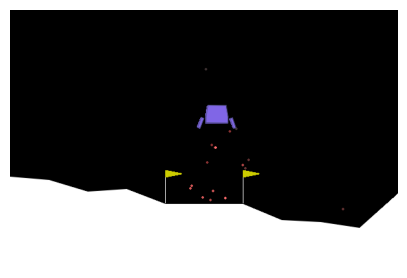

[ 0.06552849  0.5786308  -0.09863439 -0.26728898 -0.01259495 -0.02848865
  0.          0.        ]


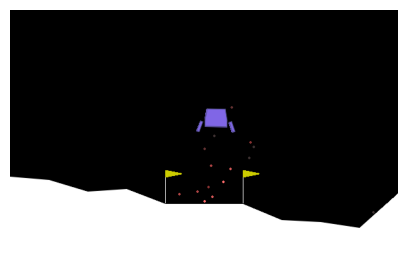

[ 0.06075306  0.5506895  -0.09889187 -0.27498576 -0.01911418 -0.03120287
  0.          0.        ]


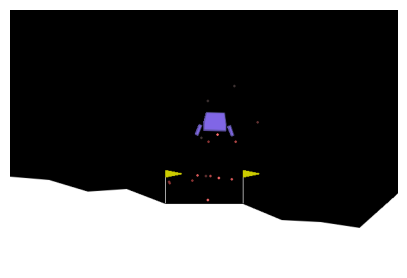

[ 0.05581627  0.5221006  -0.10838564 -0.2592319  -0.02722222 -0.04502386
  0.          0.        ]


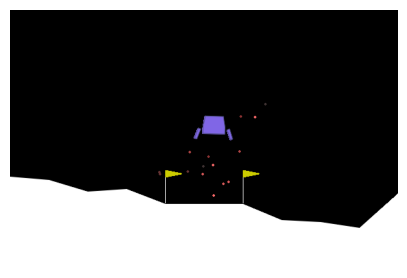

[ 0.05006618  0.49415934 -0.11456338 -0.26591712 -0.03202701 -0.01259049
  0.          0.        ]


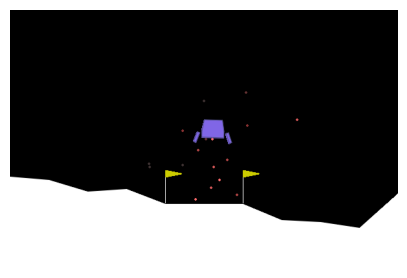

[ 0.04492206  0.46572006 -0.10718687 -0.2657169  -0.03335668 -0.01164567
  0.          0.        ]


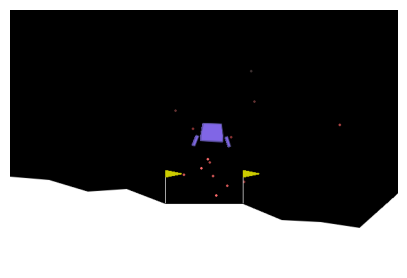

[ 0.04000711  0.4378509  -0.07780413 -0.2307335  -0.03523395  0.00837656
  0.          0.        ]


In [7]:
# If you want to look at the values after every 5 actions, use this cell instead
env = gym.make("LunarLander-v3", render_mode="rgb_array")
np.random.seed(42)
obs, info = env.reset(seed=42)
for step in range(200):
    if step%5==0:
        plot_environment(env)
        plt.show()
        print(obs)
    action = basic_policy(obs)
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        break
env.close()

## Modify the CartPole Example

Use the code below (copied from the CartPole example in class) as your starting point.  Recall that the CartPole environment only had 2 actions (push left or push right), whereas our current problem has 4 possible actions (listed above).

1. Modify the neural architecture to output probabilities for each of the 4 possible actions.
2. Change the loss function appropriately (given that we are no longer giving a binary output)
3. Replace the play_one_step function with the following:


```def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape: # Record gradients without applying them
        action_probs = model(obs[np.newaxis]) # Use model policy to determine probability of each action
        action = tf.random.categorical(tf.math.log(action_probs), num_samples=1) # Use probability to decide action
        y_target = tf.one_hot(action, depth=4) # Define target as 1-action
        y_target = tf.reshape(y_target, action_probs.shape) # Match the shape of action_probs for loss computation
        loss = tf.reduce_mean(loss_fn(y_target, action_probs)) # Compute the gradient w.r.t. loss function

    grads = tape.gradient(loss, model.trainable_variables) # Save gradients for trainable variables
    obs, reward, done, truncated, info = env.step(int(action[0,0])) # Record environment state
    return obs, reward, done, truncated, grads # Return relevant information
```


4. Increase the number of simulations per update to 100 and reduce the iterations to 30

In [8]:
n_iterations = 30
n_episodes_per_update = 100
n_max_steps = 200
discount_factor = 0.95

model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax"),
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.categorical_crossentropy

def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape:
        action_probs = model(obs[np.newaxis])
        action = tf.random.categorical(tf.math.log(action_probs), num_samples=1)
        y_target = tf.one_hot(action, depth=4)
        y_target = tf.reshape(y_target, action_probs.shape)
        loss = tf.reduce_mean(loss_fn(y_target, action_probs))

    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, truncated, info = env.step(int(action[0,0]))
    return obs, reward, done, truncated, grads

def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = play_one_step(
                env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [discount_rewards(rewards, discount_factor)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

In [ ]:
def train():
    for iteration in range(n_iterations):
        all_rewards, all_grads = play_multiple_episodes(
            env, n_episodes_per_update, n_max_steps, model, loss_fn)

        # extra code – displays some debug info during training
        total_rewards = sum(map(sum, all_rewards))
        print(f"\rIteration: {iteration + 1}/{n_iterations},"
              f" mean rewards: {total_rewards / n_episodes_per_update:.1f}", end="\n")

        all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                           discount_factor)
        all_mean_grads = []
        for var_index in range(len(model.trainable_variables)):
            mean_grads = tf.reduce_mean(
                [final_reward * all_grads[episode_index][step][var_index]
                 for episode_index, final_rewards in enumerate(all_final_rewards)
                     for step, final_reward in enumerate(final_rewards)], axis=0)
            all_mean_grads.append(mean_grads)

        optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

train()

Iteration: 1/30, mean rewards: -224.9
Iteration: 2/30, mean rewards: -211.2
Iteration: 3/30, mean rewards: -206.1
Iteration: 4/30, mean rewards: -186.4
Iteration: 5/30, mean rewards: -187.9
Iteration: 6/30, mean rewards: -188.5
Iteration: 7/30, mean rewards: -174.3
Iteration: 8/30, mean rewards: -168.2
Iteration: 9/30, mean rewards: -202.2
Iteration: 10/30, mean rewards: -175.6
Iteration: 11/30, mean rewards: -169.0
Iteration: 12/30, mean rewards: -162.8
Iteration: 13/30, mean rewards: -169.4
Iteration: 14/30, mean rewards: -166.0
Iteration: 15/30, mean rewards: -171.5
Iteration: 16/30, mean rewards: -166.0
Iteration: 17/30, mean rewards: -181.8
Iteration: 18/30, mean rewards: -178.7
Iteration: 19/30, mean rewards: -174.6
Iteration: 20/30, mean rewards: -159.4
Iteration: 21/30, mean rewards: -157.7
Iteration: 22/30, mean rewards: -156.6
Iteration: 23/30, mean rewards: -136.0
Iteration: 24/30, mean rewards: -118.8
Iteration: 25/30, mean rewards: -153.4
Iteration: 26/30, mean rewards: -1

In [2]:
# extra code – displays the animation
def pg_policy(obs):
    action_probs = model.predict(obs[np.newaxis], verbose=0)
    action = tf.random.categorical(tf.math.log(action_probs), num_samples=1) # Use probability to decide action
    return int(action[0,0])

show_one_episode(pg_policy)

NameError: name 'show_one_episode' is not defined

### Comment on the performance

In [3]:
#The model's mean reward improved from about -225 to -113 over 30 iterations, showing the policy gradient is learning, but it's still well below zero.
#Rather than landing, the model seems to have settled on a hovering strategy to avoid the -100 crash penalty.
#With only 5 hidden units and 30 iterations, the network lacks the capacity to discover a full landing behavior.

### Modify the architecture of the neural model to allow the model to learn more complex behavior
#### Try a different number of layers and neurons per layer

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax"),
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)

train()

NameError: name 'train' is not defined

In [ ]:
# extra code – displays the animation
def pg_policy(obs):
    action_probs = model.predict(obs[np.newaxis], verbose=0)
    action = tf.random.categorical(tf.math.log(action_probs), num_samples=1) # Use probability to decide action
    return int(action[0,0])

show_one_episode(pg_policy)

### Your model likely learned to hover near the top of the viewing window.  Modify the play_multiple_episodes function to encourage the model to hover closer to the landing pad by changing its rewards.  Specifically, add 5 points to the score when the lander is within 0.5 of the ground (y-value only).

In [8]:
def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = play_one_step(
                env, obs, model, loss_fn)
            # Modify the rewards
            if obs[1] < 0.5:
                reward += 5

            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

In [10]:
old_model = model
model = tf.keras.models.clone_model(old_model)
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)


train()

show_one_episode(pg_policy)

NameError: name 'train' is not defined

### Before submission, save the weights of your final model and submit along with this notebook.

In [7]:
model.save_weights('model_weights.h5')

ValueError: The filename must end in `.weights.h5`. Received: filepath=model_weights.h5